# Basetable — 2024 US Presidential Election

In [56]:
import pandas as pd
import numpy as np

# ─── Load Polymarket win probabilities as the base of the basetable ───
polymarket = pd.read_csv("../Data/1_Bronze/Polymarket/polymarket_win_probabilities.csv", parse_dates=["date"])

# Keep only Trump probability — this is the dependent variable
basetable = polymarket[["date", "Trump (%)"]].rename(columns={"Trump (%)": "polymarket_trump_prob"})
basetable["polymarket_trump_prob"] = basetable["polymarket_trump_prob"] / 100  # scale to [0, 1]

basetable = basetable.sort_values("date").reset_index(drop=True)

# Lag-1: yesterday's probability (autoregressive feature)
basetable["polymarket_trump_prob_lag1"] = basetable["polymarket_trump_prob"].shift(1)

print(f"Base: {len(basetable)} rows from {basetable['date'].min().date()} to {basetable['date'].max().date()}")
basetable.head()

Base: 124 rows from 2024-07-05 to 2024-11-05


,date,polymarket_trump_prob,polymarket_trump_prob_lag1
0,2024-07-05,0.605,NaN
1,2024-07-06,0.625,0.605
2,2024-07-07,0.625,0.625
3,2024-07-08,0.605,0.625
4,2024-07-09,0.625,0.605


# Timedimension

In [57]:
ELECTION_DAY = pd.Timestamp("2024-11-05")

# days_to_election: positive = before election, negative = after
basetable["days_to_election"] = (ELECTION_DAY - basetable["date"]).dt.days

# ISO week number
basetable["week_nr"] = basetable["date"].dt.isocalendar().week.astype(int)

basetable[["date", "days_to_election", "week_nr"]].head(10)

,date,days_to_election,week_nr
0,2024-07-05,123,27
1,2024-07-06,122,27
2,2024-07-07,121,27
3,2024-07-08,120,28
4,2024-07-09,119,28
5,2024-07-10,118,28
6,2024-07-11,117,28
7,2024-07-12,116,28
8,2024-07-13,115,28
9,2024-07-14,114,28


# Bluesky

## General

In [58]:
# ─── Load raw Bluesky posts ───
bsky_raw = pd.read_csv("../Data/2_Silver/Bluesky/bsky_US_2024_posts.csv")
bsky_raw["timestamp"] = pd.to_datetime(bsky_raw["timestamp"], format="ISO8601", utc=True)
bsky_raw["date"] = bsky_raw["timestamp"].dt.normalize().dt.tz_localize(None)

# Filter to basetable date range
bsky_raw = bsky_raw[(bsky_raw["date"] >= basetable["date"].min()) &
                    (bsky_raw["date"] <= basetable["date"].max())]

# Trump mention flag via candidate column
bsky_raw["mentions_trump"] = bsky_raw["candidate"] == "CandidateA"

# ─── Aggregate per day ───
bsky_daily = bsky_raw.groupby("date").agg(
    bsky_post_count       = ("uri",           "count"),
    bsky_trump_post_share = ("mentions_trump", "mean"),
    bsky_reply_ratio      = ("is_reply",       "mean"),
    bsky_repost_ratio     = ("reposts",        lambda x: (x > 0).mean()),
).reset_index()

# Merge into basetable
basetable = basetable.merge(bsky_daily, on="date", how="left")

basetable[["date", "bsky_post_count", "bsky_trump_post_share", "bsky_reply_ratio", "bsky_repost_ratio"]].head(10)

,date,bsky_post_count,bsky_trump_post_share,bsky_reply_ratio,bsky_repost_ratio
0,2024-07-05,36.0,0.361111,0.472222,0.222222
1,2024-07-06,23.0,0.434783,0.130435,0.130435
2,2024-07-07,27.0,0.481481,0.296296,0.148148
3,2024-07-08,22.0,0.590909,0.000000,0.454545
4,2024-07-09,33.0,0.454545,0.181818,0.181818
5,2024-07-10,39.0,0.461538,0.205128,0.179487
6,2024-07-11,62.0,0.354839,0.032258,0.112903
7,2024-07-12,43.0,0.372093,0.139535,0.139535
8,2024-07-13,32.0,0.375000,0.187500,0.250000
9,2024-07-14,100.0,0.600000,0.490000,0.310000


## Sentiment

In [59]:
# ─── Bluesky Sentiment ───
# Placeholder: sentiment analysis (VADER / TextBlob / LLM) to be added here
# Expected output columns:
#   bsky_trump_sentiment_avg  : mean sentiment of Trump-related posts [-1, 1]
#   bsky_harris_sentiment_avg : mean sentiment of Harris-related posts [-1, 1]

# TODO: run sentiment model on bsky_raw, aggregate per day, merge into basetable
print("Bluesky sentiment: to be implemented")

Bluesky sentiment: to be implemented


# Reddit 

# Newspaper

# Financials

## Market data (daily)
Weekends and holidays have no trading data → forward-fill from last known trading day.
Daily return computed as percentage change vs previous close.

In [60]:
# ─── Load market data ───
market = pd.read_csv("../Data/1_Bronze/Financials/market.csv", parse_dates=["Date"])
market = market.rename(columns={"Date": "date"})
market = market.sort_values("date").reset_index(drop=True)

# Daily return of S&P500 (% change vs previous trading day)
market["sp500_return_1d"] = market["SP500"].pct_change() * 100

# Rename to clean column names
market = market.rename(columns={
    "SP500":        "sp500_close",
    "Oil":          "oil_close",
    "VIX":          "vix_close",
    "TenYearBond":  "bond_10y",
    "USDIndex":     "usd_index",
})

# ─── Reindex to full daily range and forward-fill weekends/holidays ───
# Basetable has 7 days/week → market only has trading days → ffill gaps
full_range = pd.DataFrame({"date": pd.date_range(market["date"].min(), market["date"].max())})
market = full_range.merge(market, on="date", how="left").ffill()

# Merge into basetable
basetable = basetable.merge(
    market[["date", "sp500_close", "sp500_return_1d", "oil_close", "vix_close", "bond_10y", "usd_index"]],
    on="date", how="left"
)

basetable[["date", "sp500_close", "sp500_return_1d", "vix_close", "usd_index"]].head(10)

,date,sp500_close,sp500_return_1d,vix_close,usd_index
0,2024-07-05,5567.189941,NaN,12.48,104.879997
1,2024-07-06,5567.189941,NaN,12.48,104.879997
2,2024-07-07,5567.189941,NaN,12.48,104.879997
3,2024-07-08,5572.850098,0.101670,12.37,105.010002
4,2024-07-09,5576.979980,0.074107,12.51,105.120003
5,2024-07-10,5633.910156,1.020807,12.85,105.050003
6,2024-07-11,5584.540039,-0.876303,12.92,104.440002
7,2024-07-12,5615.350098,0.551703,12.46,104.089996
8,2024-07-13,5615.350098,0.551703,12.46,104.089996
9,2024-07-14,5615.350098,0.551703,12.46,104.089996


## Macro data (monthly)
Published once a month → forward-fill to each day until the next release.
This correctly reflects what was *known* on each day (no lookahead bias).

In [61]:
# ─── Load macro data ───
macros = pd.read_csv("../Data/1_Bronze/Financials/macros.csv", parse_dates=["DATE"])
macros = macros.rename(columns={"DATE": "date"})
macros = macros.sort_values("date").reset_index(drop=True)

# ─── Forward-fill monthly values to daily ───
# Merge on full daily range, then ffill → each day gets the last known macro value
full_range = pd.DataFrame({"date": pd.date_range(basetable["date"].min(), basetable["date"].max())})
macros_daily = full_range.merge(macros, on="date", how="left").ffill()

# RealGDP is quarterly → many NaN even after ffill at start; ffill handles it
# Drop rows still NaN at the very start (before first macro release)
macros_daily = macros_daily.rename(columns={
    "RealDisposableIncome": "macro_real_income",
    "RealGDP":              "macro_real_gdp",
    "UnemploymentRate":     "macro_unemployment",
    "CPIInflation":         "macro_cpi",
    "ConsumerSentiment":    "macro_consumer_sentiment",
})

# Merge into basetable
basetable = basetable.merge(macros_daily, on="date", how="left")

basetable[["date", "macro_unemployment", "macro_cpi", "macro_consumer_sentiment"]].head(10)

,date,macro_unemployment,macro_cpi,macro_consumer_sentiment
0,2024-07-05,NaN,NaN,NaN
1,2024-07-06,NaN,NaN,NaN
2,2024-07-07,NaN,NaN,NaN
3,2024-07-08,NaN,NaN,NaN
4,2024-07-09,NaN,NaN,NaN
5,2024-07-10,NaN,NaN,NaN
6,2024-07-11,NaN,NaN,NaN
7,2024-07-12,NaN,NaN,NaN
8,2024-07-13,NaN,NaN,NaN
9,2024-07-14,NaN,NaN,NaN


# Financials

In [62]:
print(f"Basetable shape: {basetable.shape}")
print(f"Columns: {list(basetable.columns)}")
basetable

Basetable shape: (124, 20)
Columns: ['date', 'polymarket_trump_prob', 'polymarket_trump_prob_lag1', 'days_to_election', 'week_nr', 'bsky_post_count', 'bsky_trump_post_share', 'bsky_reply_ratio', 'bsky_repost_ratio', 'sp500_close', 'sp500_return_1d', 'oil_close', 'vix_close', 'bond_10y', 'usd_index', 'macro_real_income', 'macro_real_gdp', 'macro_unemployment', 'macro_cpi', 'macro_consumer_sentiment']


,date,polymarket_trump_prob,polymarket_trump_prob_lag1,days_to_election,week_nr,bsky_post_count,bsky_trump_post_share,bsky_reply_ratio,bsky_repost_ratio,sp500_close,sp500_return_1d,oil_close,vix_close,bond_10y,usd_index,macro_real_income,macro_real_gdp,macro_unemployment,macro_cpi,macro_consumer_sentiment
0,2024-07-05,0.6050,NaN,123,27,36.0,0.361111,0.472222,0.222222,5567.189941,NaN,83.160004,12.480000,4.272,104.879997,NaN,NaN,NaN,NaN,NaN
1,2024-07-06,0.6250,0.6050,122,27,23.0,0.434783,0.130435,0.130435,5567.189941,NaN,83.160004,12.480000,4.272,104.879997,NaN,NaN,NaN,NaN,NaN
2,2024-07-07,0.6250,0.6250,121,27,27.0,0.481481,0.296296,0.148148,5567.189941,NaN,83.160004,12.480000,4.272,104.879997,NaN,NaN,NaN,NaN,NaN
3,2024-07-08,0.6050,0.6250,120,28,22.0,0.590909,0.000000,0.454545,5572.850098,0.101670,82.330002,12.370000,4.269,105.010002,NaN,NaN,NaN,NaN,NaN
4,2024-07-09,0.6250,0.6050,119,28,33.0,0.454545,0.181818,0.181818,5576.979980,0.074107,81.410004,12.510000,4.300,105.120003,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,2024-11-01,0.5825,0.6325,4,44,764.0,0.506545,0.297120,0.294503,5728.799805,0.409251,69.489998,21.879999,4.361,104.279999,17851.4,23586.542,4.2,316.528,71.8
120,2024-11-02,0.5585,0.5825,3,44,668.0,0.477545,0.326347,0.247006,NaN,NaN,NaN,NaN,NaN,NaN,17851.4,23586.542,4.2,316.528,71.8
121,2024-11-03,0.5635,0.5585,2,44,875.0,0.368000,0.342857,0.270857,NaN,NaN,NaN,NaN,NaN,NaN,17851.4,23586.542,4.2,316.528,71.8
122,2024-11-04,0.5855,0.5635,1,45,1172.0,0.344710,0.308020,0.261092,NaN,NaN,NaN,NaN,NaN,NaN,17851.4,23586.542,4.2,316.528,71.8


# Political Data

In [63]:
# ─── debate_day: presidential debate dates ───
# June 27 = Biden-Trump (CNN) — outside our data range (starts July 5)
# September 10 = Harris-Trump (ABC)
basetable["debate_day"]      = basetable["date"].isin(pd.to_datetime(["2024-09-10"])).astype(int)
basetable["debate_day_lag1"] = basetable["debate_day"].shift(1).fillna(0).astype(int)
basetable["debate_day_lag2"] = basetable["debate_day"].shift(2).fillna(0).astype(int)

# ─── Event dummies: one per event ───
def event_dummy(dates, lag=0):
    flags = basetable["date"].isin(pd.to_datetime(dates)).astype(int)
    return flags.shift(lag).fillna(0).astype(int)

# Assassination attempt 1 — July 13 (Butler, PA)
basetable["event_assassination1"]      = event_dummy(["2024-07-13"])
basetable["event_assassination1_lag1"] = event_dummy(["2024-07-13"], lag=1)

# Biden drops out — July 21
basetable["event_biden_out"]      = event_dummy(["2024-07-21"])
basetable["event_biden_out_lag1"] = event_dummy(["2024-07-21"], lag=1)

# Harris nominated — August 19
basetable["event_harris_nom"]      = event_dummy(["2024-08-19"])
basetable["event_harris_nom_lag1"] = event_dummy(["2024-08-19"], lag=1)

# Assassination attempt 2 — September 15
basetable["event_assassination2"]      = event_dummy(["2024-09-15"])
basetable["event_assassination2_lag1"] = event_dummy(["2024-09-15"], lag=1)

# Preview: only rows where something happened
event_cols = [c for c in basetable.columns if c.startswith("event_") or c.startswith("debate_")]
basetable[["date"] + event_cols].loc[basetable[event_cols].sum(axis=1) > 0]

,date,debate_day,debate_day_lag1,debate_day_lag2,event_assassination1,event_assassination1_lag1,event_biden_out,event_biden_out_lag1,event_harris_nom,event_harris_nom_lag1,event_assassination2,event_assassination2_lag1
8,2024-07-13,0,0,0,1,0,0,0,0,0,0,0
9,2024-07-14,0,0,0,0,1,0,0,0,0,0,0
16,2024-07-21,0,0,0,0,0,1,0,0,0,0,0
17,2024-07-22,0,0,0,0,0,0,1,0,0,0,0
45,2024-08-19,0,0,0,0,0,0,0,1,0,0,0
46,2024-08-20,0,0,0,0,0,0,0,0,1,0,0
67,2024-09-10,1,0,0,0,0,0,0,0,0,0,0
68,2024-09-11,0,1,0,0,0,0,0,0,0,0,0
69,2024-09-12,0,0,1,0,0,0,0,0,0,0,0
72,2024-09-15,0,0,0,0,0,0,0,0,0,1,0


# Modelling

In [64]:
# ─── Target variable: next day's Trump win probability (continuous) ───
df = basetable.copy()
df["target"] = df["polymarket_trump_prob"].shift(-1)

# ─── Features ───
FEATURES = [
    # Autoregressive
    "polymarket_trump_prob",
    "polymarket_trump_prob_lag1",

    # Time
    "days_to_election",
    "week_nr",

    # Bluesky
    "bsky_post_count",
    "bsky_trump_post_share",
    "bsky_reply_ratio",
    "bsky_repost_ratio",

    # Market
    "sp500_close",
    "sp500_return_1d",
    "oil_close",
    "vix_close",
    "bond_10y",
    "usd_index",

    # Macro (macro_real_gdp excluded: quarterly data → NaN for most rows)
    "macro_unemployment",
    "macro_cpi",
    "macro_consumer_sentiment",
    "macro_real_income",

    # Political events
    "debate_day",
    "debate_day_lag1",
    "debate_day_lag2",
    "event_assassination1",
    "event_assassination1_lag1",
    "event_biden_out",
    "event_biden_out_lag1",
    "event_harris_nom",
    "event_harris_nom_lag1",
    "event_assassination2",
    "event_assassination2_lag1",
]

# Drop rows with missing target or features
df = df.dropna(subset=FEATURES + ["target"]).reset_index(drop=True)
print(f"Usable rows after dropping NaN: {len(df)}")
print(f"Features: {len(FEATURES)}")
print(f"Target range: [{df['target'].min():.3f}, {df['target'].max():.3f}]")

Usable rows after dropping NaN: 93
Features: 29
Target range: [0.443, 0.665]


In [65]:
# ─── Chronological train / val / test split ───
# Must be chronological — no random split for time series!
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train = df.iloc[:train_end]
val   = df.iloc[train_end:val_end]
test  = df.iloc[val_end:]

X_train, y_train = train[FEATURES], train["target"]
X_val,   y_val   = val[FEATURES],   val["target"]
X_test,  y_test  = test[FEATURES],  test["target"]

print(f"Train: {len(train)} rows  ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Val:   {len(val)}  rows  ({val['date'].min().date()} → {val['date'].max().date()})")
print(f"Test:  {len(test)} rows  ({test['date'].min().date()} → {test['date'].max().date()})")
print(f"\nFeatures used: {len(FEATURES)}")

Train: 65 rows  (2024-08-01 → 2024-10-04)
Val:   14  rows  (2024-10-05 → 2024-10-18)
Test:  14 rows  (2024-10-19 → 2024-11-01)

Features used: 29


In [66]:
from sklearn.linear_model  import Ridge
from sklearn.ensemble      import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import mean_absolute_error, root_mean_squared_error, r2_score, roc_auc_score

# ─── Scale features (needed for Ridge) ───
scaler  = StandardScaler()
Xtr_sc  = scaler.fit_transform(X_train)
Xval_sc = scaler.transform(X_val)
Xte_sc  = scaler.transform(X_test)

# ─── Models ───
models = {
    "Ridge Regression":  Ridge(alpha=1.0),
    "Random Forest":     RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42),
}

# ─── Evaluate ───
def evaluate(model, X, y, scaled=False):
    Xin  = scaler.transform(X) if scaled else X
    pred = model.predict(Xin)
    today = X["polymarket_trump_prob"].values

    # Directional accuracy: did we predict the right direction?
    dir_acc = np.mean(np.sign(pred - today) == np.sign(y.values - today))

    # AUC: use predicted change as score, actual direction as binary label
    # → "does a higher predicted change correspond to actual up days?"
    actual_up   = (y.values > today).astype(int)
    pred_change = pred - today
    auc = roc_auc_score(actual_up, pred_change) if actual_up.sum() > 0 and actual_up.sum() < len(actual_up) else float("nan")

    return {
        "AUC":      round(auc, 3),
        "Dir. Acc": round(dir_acc, 3),
        "MAE":      round(mean_absolute_error(y, pred), 4),
        "RMSE":     round(root_mean_squared_error(y, pred), 4),
        "R²":       round(r2_score(y, pred), 3),
    }

rows = []
for name, model in models.items():
    scaled = isinstance(model, Ridge)
    Xtr = Xtr_sc if scaled else X_train
    model.fit(Xtr, y_train)

    for split, X, y in [("val", X_val, y_val), ("test", X_test, y_test)]:
        metrics = evaluate(model, X, y, scaled=scaled)
        rows.append({"Model": name, "Split": split, **metrics})

results = pd.DataFrame(rows)
results

,Model,Split,AUC,Dir. Acc,MAE,RMSE,R²
0,Ridge Regression,val,0.675,0.286,0.0256,0.0301,0.053
1,Ridge Regression,test,0.490,0.500,0.0417,0.0460,-1.472
2,Random Forest,val,0.675,0.357,0.0492,0.0576,-2.470
3,Random Forest,test,0.592,0.500,0.1201,0.1238,-16.926


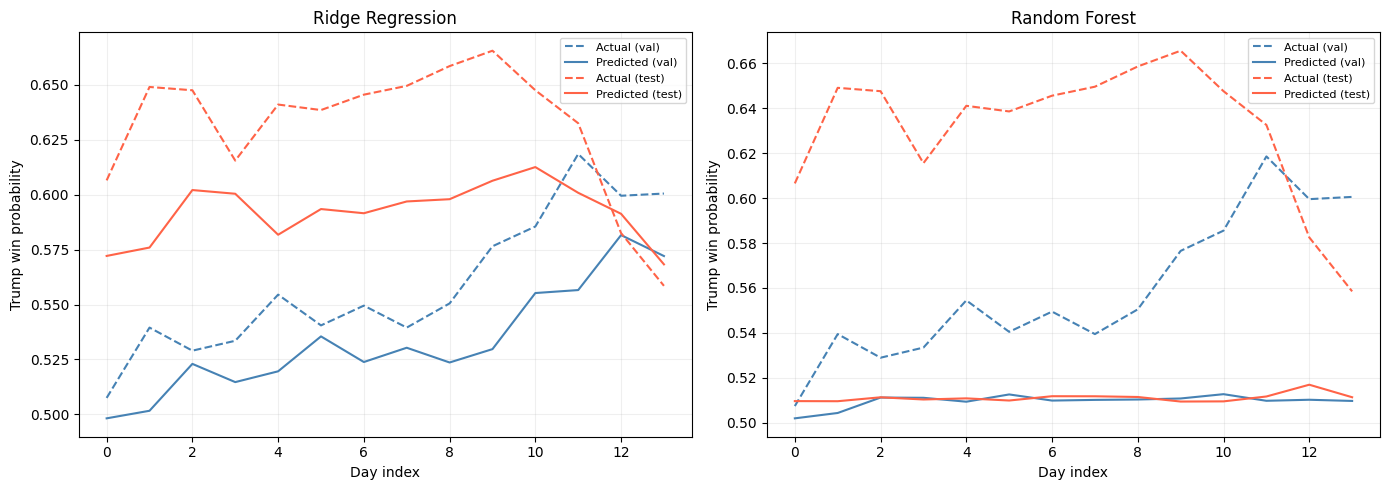

In [67]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, models.items()):
    scaled = isinstance(model, Ridge)
    for split, X, y, color in [("val", X_val, y_val, "steelblue"), ("test", X_test, y_test, "tomato")]:
        Xin  = scaler.transform(X) if scaled else X
        pred = model.predict(Xin)
        ax.plot(y.values,  label=f"Actual ({split})",    color=color, linewidth=1.5, linestyle="--")
        ax.plot(pred,      label=f"Predicted ({split})", color=color, linewidth=1.5)

    ax.set_title(name)
    ax.set_ylabel("Trump win probability")
    ax.set_xlabel("Day index")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()